# Collecte des résultats de similarité

**Projet** : Gallica Images — Analyse d'illustrations des Métamorphoses d'Ovide  
**Date**   : Avril 2026

Ce notebook interroge l'API Fouille d'image BnF pour récupérer les r illustrations
les plus similaires dans Gallica pour chacune des 184 gravures de Bernard Salomon (1557).

**Entrée**  : API BnF — endpoint `/api/ouvrages/{ark}/illustrations`  
**Sortie**  : `resultats/csv/salomon_segmente.csv` — 184*r lignes

---

## 1. Configuration

In [3]:
import sys
sys.path.insert(0, "..")
from gallica_utils import BASE_URL, ARK_SALOMON

import requests
import pandas as pd
import time
import os

os.makedirs("../../resultats/csv", exist_ok=True)
print(f"API : {BASE_URL}")
print(f"ARK Salomon : {ARK_SALOMON}")

API : https://gallica-search-api-preprod.bnf.lajavaness.com
ARK Salomon : btv1b2200047r


## 2. Récupérer les illustrations Salomon avec leurs embeddings CLIP

In [4]:
r = requests.get(f"{BASE_URL}/api/ouvrages/{ARK_SALOMON}/illustrations", timeout=30)
illustrations = r.json()

# Garder uniquement celles qui ont un vecteur CLIP valide (768 dimensions)
valides = [
    illus for illus in illustrations
    if illus.get("metas", {}).get("content_embedding")
    and len(illus["metas"]["content_embedding"]) == 768
]

print(f"Illustrations totales       : {len(illustrations)}")
print(f"Illustrations avec vecteur  : {len(valides)}")

Illustrations totales       : 184
Illustrations avec vecteur  : 184


## 2.5 Chargement des vignettes segmentées

Pour chaque illustration Salomon, on charge la vignette segmentée par YOLO
depuis `segmentees/bois_salomon_rouille_lyon1557/` et on calcule
son embedding CLIP via `POST /api/image` — au lieu d'utiliser l'embedding
précalculé sur la page entière.

In [5]:
import json
from pathlib import Path

DOSSIER_SEG = "../../data/bois_cuivre/segmentees/bois_salomon_rouille_lyon1557"

def embedding_depuis_vignette(page):
    """
    Charge la vignette segmentée correspondant à la page Salomon
    et retourne son vecteur CLIP via POST /api/image.
    Retourne None si aucune vignette trouvée.
    """
    candidats = [
        f for f in os.listdir(DOSSIER_SEG)
        if f"_f{page:03d}_" in f and "_flip" not in f
    ]
    if not candidats:
        return None

    chemin = f"{DOSSIER_SEG}/{sorted(candidats)[0]}"
    with open(chemin, "rb") as f:
        img_bytes = f.read()

    r = requests.post(
        f"{BASE_URL}/api/image",
        files={"image": ("image.jpg", img_bytes, "image/jpeg")},
        timeout=30
    )
    if r.status_code == 200:
        return json.loads(r.text)
    return None

# Test sur la première illustration
page_test   = valides[0]["view_number"]
vecteur_test = embedding_depuis_vignette(page_test)
if vecteur_test:
    print(f"✓ Test page {page_test} — vecteur CLIP : {len(vecteur_test)} dimensions")
else:
    print(f"✗ Aucune vignette trouvée pour page {page_test}")

✓ Test page 1 — vecteur CLIP : 768 dimensions


## 3. Recherche par similarité — boucle sur toutes les illustrations

Pour chaque illustration, on envoie son vecteur CLIP à l'API et on récupère les r résultats les plus similaires dans Gallica.

In [6]:
# Paramètre modifiable : nombre de résultats par illustration
N_RESULTATS = 50

resultats = []
total     = len(valides)

for i, illus in enumerate(valides):
    print(f"  {i+1}/{total} — page {illus['view_number']}...", end="\r")

    try:
        r = requests.post(
            f"{BASE_URL}/api/search",
            json={
                "type"        : "image",
                "image_vector": embedding_depuis_vignette(illus["view_number"]),
                "rows"        : N_RESULTATS,
                "start"       : 0
            },
            headers={"Content-Type": "application/json"},
            timeout=30
        )
        docs = r.json()["response"]["docs"]

        for doc in docs:
            resultats.append({
                "salomon_page" : illus["view_number"],
                "salomon_ark"  : illus["ark"],
                "score"        : round(doc.get("score", 0), 4),
                "titre"        : (doc.get("context_title")  or [""])[0][:80],
                "auteur"       : (doc.get("context_author") or [""])[0][:50],
                "date"         : str(doc.get("context_date", ""))[:10],
                "corpus"       : (doc.get("context_corpus") or [""])[0][:60],
                "technique"    : (doc.get("properties_technical_category") or [""])[0],
                "categorie"    : (doc.get("properties_form_function")       or [""])[0],
                "genre"        : (doc.get("properties_genre")               or [""])[0],
                "palette"      : ", ".join(doc.get("physical_palette")      or []),
                "chromatic_mode": doc.get("physical_chromatic_mode", ""),
                "link"         : doc.get("link", ""),
                "result_ark"   : doc.get("ark",  "")
            })

        time.sleep(0.1)

    except Exception as e:
        print(f"\n  Erreur page {illus['view_number']} : {e}")

print(f"\n✓ {len(resultats)} résultats collectés pour {total} illustrations")

  6/184 — page 6...
  Erreur page 6 : 'response'
  26/184 — page 26...
  Erreur page 26 : 'response'
  31/184 — page 31...
  Erreur page 31 : 'response'
  37/184 — page 37...
  Erreur page 37 : 'response'
  48/184 — page 47...
  Erreur page 47 : 'response'
  75/184 — page 73...
  Erreur page 73 : 'response'
  85/184 — page 83...
  Erreur page 83 : 'response'
  92/184 — page 90...
  Erreur page 90 : 'response'
  118/184 — page 116...
  Erreur page 116 : 'response'
  121/184 — page 119...
  Erreur page 119 : 'response'
  122/184 — page 120...
  Erreur page 120 : 'response'
  123/184 — page 120...
  Erreur page 120 : 'response'
  132/184 — page 129...
  Erreur page 129 : 'response'
  134/184 — page 131...
  Erreur page 131 : 'response'
  155/184 — page 152...
  Erreur page 152 : 'response'
  161/184 — page 158...
  Erreur page 158 : 'response'
  162/184 — page 159...
  Erreur page 159 : 'response'
  168/184 — page 165...
  Erreur page 165 : 'response'
  184/184 — page 181...
✓ 8300 résult

## 4. Sauvegarde

In [7]:
df = pd.DataFrame(resultats)

chemin_csv = "../../resultats/csv/salomon_segmente.csv"
df.to_csv(chemin_csv, index=False)

print(f"✓ CSV sauvegardé : {chemin_csv}")
print(f"  Shape          : {df.shape}")
print(f"  Colonnes       : {df.columns.tolist()}")
df.head(5)

✓ CSV sauvegardé : ../../resultats/csv/salomon_segmente.csv
  Shape          : (8300, 14)
  Colonnes       : ['salomon_page', 'salomon_ark', 'score', 'titre', 'auteur', 'date', 'corpus', 'technique', 'categorie', 'genre', 'palette', 'chromatic_mode', 'link', 'result_ark']


,salomon_page,salomon_ark,score,titre,auteur,date,corpus,technique,categorie,genre,palette,chromatic_mode,link,result_ark
0,1,bfkfk930z5q,0.9953,[Illustrations de La Métamorphose d'Ovide figu...,Ovide (0043 av. J.-C.-0017). Auteur du texte,1557,,estampe,Ornement typographique,Représentations humaines / Portraits,"blanc, gris, noir",nb,https://openapi.bnf.fr/iiif/image/v3/ark:/1214...,bfkfk930z5q
1,1,bfkfk930z5q,0.9510,Argomento della Galleria Farnese dipinta da An...,"Carracci, Annibale (1560-1609). Peintre",1657,,estampe,Jeu,Représentations humaines / Figures,"blanc, gris, noir",nb,https://openapi.bnf.fr/iiif/image/v3/ark:/1214...,bfkfk84x792
2,1,bfkfk930z5q,0.9507,Les galeries publiques de l'Europe. T1 / par J...,"Armengaud, Jean Germain Désiré (1797-1869). Au...",[1859 TO 1,,estampe,Illustration scientifique / Général,,"noir, blanc, gris",nb,https://openapi.bnf.fr/iiif/image/v3/ark:/1214...,bfkfkb82p56
3,1,bfkfk930z5q,0.9499,Argomento della Galleria Farnese dipinta da An...,"Carracci, Annibale (1560-1609). Peintre",1657,,estampe,Ornement typographique,Représentations humaines / Figures,"blanc, gris, noir",nb,https://openapi.bnf.fr/iiif/image/v3/ark:/1214...,bfkfk84x77c
4,1,bfkfk930z5q,0.9492,Les galeries publiques de l'Europe. T1 / par J...,"Armengaud, Jean Germain Désiré (1797-1869). Au...",[1859 TO 1,,photographie,Illustration scientifique / Général,,"noir, blanc, gris",nb,https://openapi.bnf.fr/iiif/image/v3/ark:/1214...,bfkfkbrh77t


In [3]:
import pandas as pd, os

RACINE = os.path.abspath("../../")
df = pd.read_csv(os.path.join(RACINE, "resultats", "csv", "salomon_enrichi_segmente.csv"))

# ── Identifier la première page de Salomon ──────────────────
premiere = sorted(df["salomon_page"].unique())[0]
print(f"Page Salomon requête : {premiere}\n")

# ── Ses résultats, triés par score décroissant ──────────────
sous = df[df["salomon_page"] == premiere].sort_values("score", ascending=False)
top3 = sous.head(3)

print("Les 3 images les plus similaires :\n")
for i, (_, r) in enumerate(top3.iterrows(), 1):
    print(f"{i}. score={r['score']:.3f} | {str(r['titre'])[:55]}")
    print(f"   {r['date']} · {r['technique']}")
    print(f"   {r['link']}\n")

Page Salomon requête : 1

Les 3 images les plus similaires :

1. score=0.995 | [Illustrations de La Métamorphose d'Ovide figurée] / Be
   1557 · estampe
   https://openapi.bnf.fr/iiif/image/v3/ark:/12148/btv1b2200047r/f1/pct:2.9948,10.9697,86.3501,81.1001/max/0/default.jpg

2. score=0.951 | Argomento della Galleria Farnese dipinta da Annibale Ca
   1657 · estampe
   https://openapi.bnf.fr/iiif/image/v3/ark:/12148/btv1b100714177/f36/pct:10.5966,22.2710,28.1257,46.1835/max/0/default.jpg

3. score=0.951 | Les galeries publiques de l'Europe. T1 / par J.-G.-D. A
   [1859 TO 1 · estampe
   https://openapi.bnf.fr/iiif/image/v3/ark:/12148/bpt6k433038d/f21/pct:26.5494,15.1693,38.3974,12.2708/max/0/default.jpg



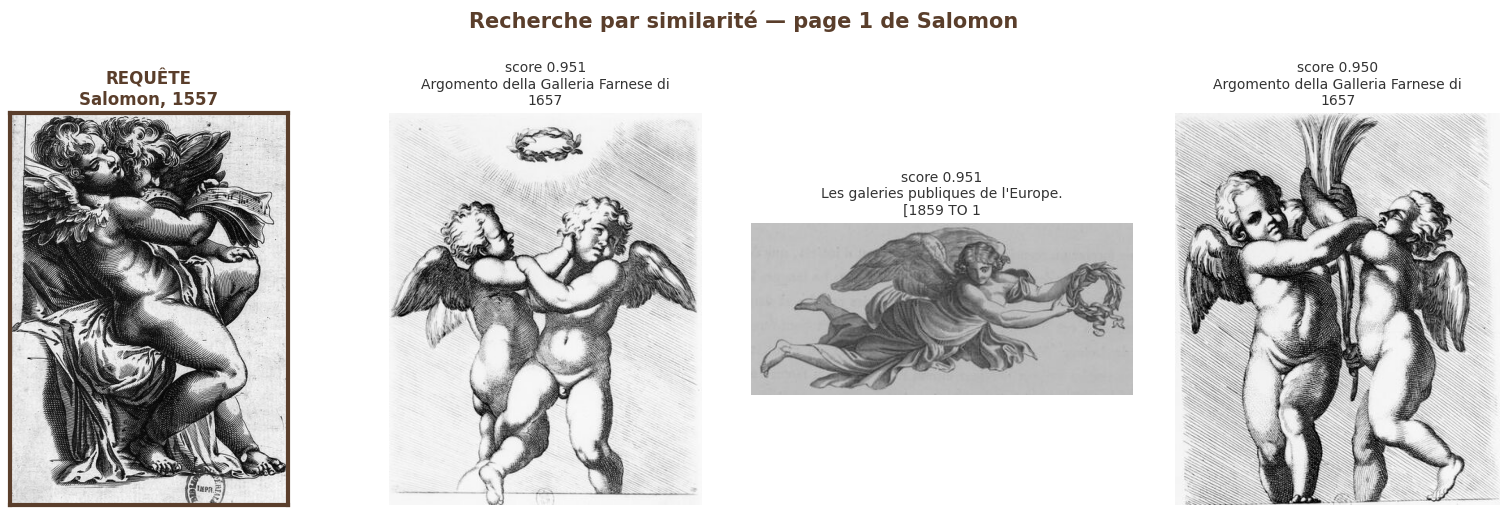

✓ Image sauvegardée : /mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir/resultats/visualisations/similarite_salomon_page1.png


In [8]:
import pandas as pd, os, re, requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

RACINE = os.path.abspath("../../")
df = pd.read_csv(os.path.join(RACINE, "resultats", "csv", "salomon_enrichi_segmente.csv"))

def vignette(url):
    return re.sub(r"/max/0/", "/400,/0/", str(url))

def charger_image(url):
    """Télécharge une image IIIF et la renvoie en objet PIL."""
    r = requests.get(vignette(url), timeout=30)
    r.raise_for_status()
    return Image.open(BytesIO(r.content)).convert("RGB")

def visuel_similarite(page, dossier_sortie):
    sous = df[df["salomon_page"] == page].sort_values("score", ascending=False)
    top = sous.head(4)   # 1 requête (elle-même) + 3 voisines

    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    for ax, (i, (_, r)) in zip(axes, enumerate(top.iterrows())):
        try:
            img = charger_image(r["link"])
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, "image\nindisponible", ha="center", va="center")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"REQUÊTE\nSalomon, {r['date']}",
                         fontsize=12, fontweight="bold", color="#5a3e2b")
            # cadre épais autour de la requête
            for spine in ax.spines.values():
                spine.set_visible(True); spine.set_linewidth(3); spine.set_edgecolor("#5a3e2b")
            ax.axis("on"); ax.set_xticks([]); ax.set_yticks([])
        else:
            titre = str(r["titre"]).replace("[","").replace("]","")[:35]
            ax.set_title(f"score {r['score']:.3f}\n{titre}\n{r['date']}",
                         fontsize=10, color="#333")

    fig.suptitle(f"Recherche par similarité — page {page} de Salomon",
                 fontsize=15, fontweight="bold", color="#5a3e2b", y=1.02)
    plt.tight_layout()

    chemin = os.path.join(dossier_sortie, f"similarite_salomon_page{page}.png")
    plt.savefig(chemin, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Image sauvegardée : {chemin}")

# ── PAGE 1 ──────────────────────────────────────────────────
DOSSIER = os.path.join(RACINE, "resultats", "visualisations")
os.makedirs(DOSSIER, exist_ok=True)
visuel_similarite(1, DOSSIER)

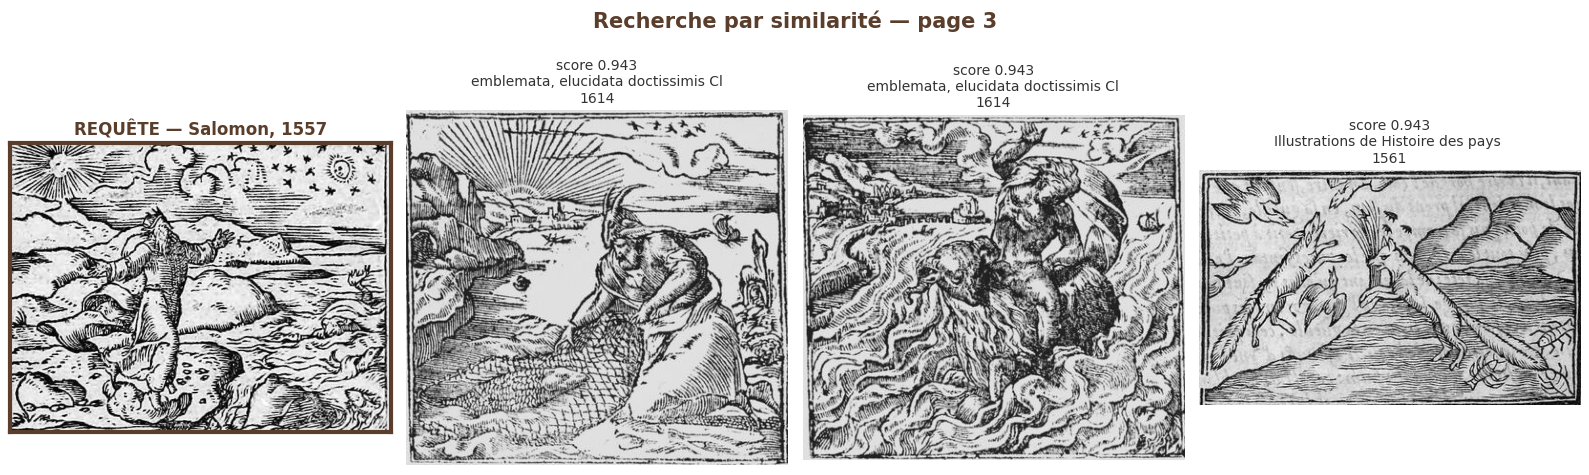

✓ Image sauvegardée : /mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir/resultats/visualisations/similarite_salomon_page3.png


In [16]:
import pandas as pd, os, re, requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

RACINE = os.path.abspath("../../")
df = pd.read_csv(os.path.join(RACINE, "resultats", "csv", "salomon_enrichi_segmente.csv"))

# ── Image requête locale ─────────────────────────────────────
IMAGE_REQUETE = "/mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir/data/bois_cuivre/segmentees/bois_salomon_rouille_lyon1557/salomon_f003_det1_conf0.87.jpg"

def vignette(url):
    return re.sub(r"/max/0/", "/400,/0/", str(url))

def charger_image(url):
    """Télécharge une image IIIF et la renvoie en objet PIL."""
    r = requests.get(vignette(url), timeout=30)
    r.raise_for_status()
    return Image.open(BytesIO(r.content)).convert("RGB")

def visuel_similarite(page, dossier_sortie):
    sous = df[df["salomon_page"] == page].sort_values("score", ascending=False)
    top = sous.head(4)   # 1 requête + 3 voisins

    fig, axes = plt.subplots(1, 4, figsize=(16, 5))

    for ax, (i, (_, r)) in zip(axes, enumerate(top.iterrows())):
        try:
            if i == 0:
                img = Image.open(IMAGE_REQUETE).convert("RGB")
            else:
                img = charger_image(r["link"])

            ax.imshow(img)

        except Exception:
            ax.text(0.5, 0.5, "image\nindisponible",
                    ha="center", va="center")

        ax.axis("off")

        if i == 0:
            ax.set_title("REQUÊTE — Salomon, 1557",
                         fontsize=12, fontweight="bold", color="#5a3e2b")

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(3)
                spine.set_edgecolor("#5a3e2b")

            ax.axis("on")
            ax.set_xticks([])
            ax.set_yticks([])

        else:
            titre = str(r["titre"]).replace("[", "").replace("]", "")[:35]
            ax.set_title(f"score {r['score']:.3f}\n{titre}\n{r['date']}",
                         fontsize=10, color="#333")

    fig.suptitle(f"Recherche par similarité — page {page}",
                 fontsize=15, fontweight="bold", color="#5a3e2b", y=1.02)

    plt.tight_layout()

    chemin = os.path.join(dossier_sortie,
                          f"similarite_salomon_page{page}.png")

    plt.savefig(chemin, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"✓ Image sauvegardée : {chemin}")


# ── PAGE 3 ──────────────────────────────────────────────────
DOSSIER = os.path.join(RACINE, "resultats", "visualisations")
os.makedirs(DOSSIER, exist_ok=True)

visuel_similarite(3, DOSSIER)

In [10]:
import os

for root, dirs, files in os.walk(os.path.join(RACINE, "data", "segmentees")):
    for f in files:
        if "salomon_f003" in f:
            print(os.path.join(root, f))

/mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir/data/bois_cuivre/segmentees/bois_salomon_rouille_lyon1557/salomon_f003_det1_conf0.87.jpg
